In [2]:
import os
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

sns.set(font_scale=1.5)
sns.set_style('ticks')

plt.rcParams.update({
    'axes.titlesize': 'large',
    'axes.labelsize': 'large',
    'xtick.labelsize':'large',
    'ytick.labelsize':'large'
    })


# Experiment 1

In [3]:
# sub = 5
main_acc_df = []
main_acc_cols = ['subject', 'metric', 'value']

for sub in range(5, 36):
    filepath = f'/home/nmuller/projects/fmg_storage/Data/sub_{sub}'
    filename = [x for x in os.listdir(filepath) if x.endswith('.csv') and 'FMG1441_Object_Classification_EEG' in x]
    if len(filename) == 0:
        continue
    filename = filename[0]
    # f'sub_{sub}_FMG1441_Object_Classification_EEG_2023-04-04_10h25.38.675.csv'
    
    beh = pd.read_csv(os.path.join(filepath, filename), sep=',', low_memory=False)
    acc = beh[~(beh['key_resp.corr'].isna())]['key_resp.corr'].mean()

    main_acc_df.append([
        sub,
        'accuracy',
        acc
    ])

main_acc_df = pd.DataFrame(main_acc_df, columns=main_acc_cols)

In [4]:
print(f'Mean accuracy: {main_acc_df["value"].mean():.3f} +- {main_acc_df["value"].std():.3f}')

Mean accuracy: 0.980 +- 0.019


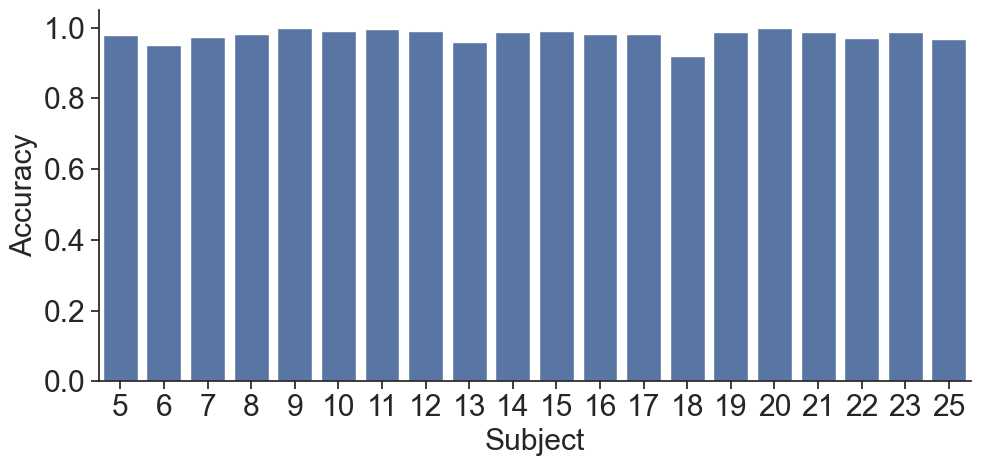

In [5]:

g = sns.catplot(data=main_acc_df, x='subject', y='value', kind='bar', height=5, aspect=2)

g.set_axis_labels('Subject', 'Accuracy')

plt.show()

# Experiment 2

In [6]:
# sub = 1
# ses = 1
acc_df = []
acc_cols = ['Subject', 'Session', 'metric', 'value']

for sub in [1, 2, 3, 4]:
    for ses in range(1, 7):
        filepath = f'/home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_experiment/data_clean/base_dir_reordered/behavioral_raw_data/sub{str(sub).zfill(3)}/sub{str(sub).zfill(3)}_ses{str(ses).zfill(3)}.csv'
        beh = pd.read_csv(filepath, sep=',', low_memory=False)
        acc = beh[~(beh['key_resp.corr'].isna())]['key_resp.corr'].mean()

        acc_df.append([
            sub,
            ses,
            'accuracy',
            acc
        ])

for sub in [12, 15, 16, 17, 18, 19]: # 
    filepath = f'/home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_experiment/data_SECOND_BATCH/sub{str(sub).zfill(3)}'
    # for ses in range(1, 7):
    filenames = [x for x in os.listdir(filepath) if x.endswith('.csv') and 'no_eyetracker' not in x]

    for filename in filenames:
        ses = filename.split('_ses')[1].split('.')[0]
        ses_int = int(ses.split('_')[0])
        beh = pd.read_csv(os.path.join(filepath, filename), sep=',', low_memory=False)
        if 'key_resp.corr' not in beh.columns:
            continue
        acc = beh[~(beh['key_resp.corr'].isna())]['key_resp.corr'].mean()

        acc_df.append([
            sub,
            ses_int,
            'accuracy',
            acc
        ])

acc_df = pd.DataFrame(acc_df, columns=acc_cols)

In [7]:
print(f'Mean accuracy: {acc_df["value"].mean():.3f} +- {acc_df["value"].std():.3f}')

Mean accuracy: 0.923 +- 0.110


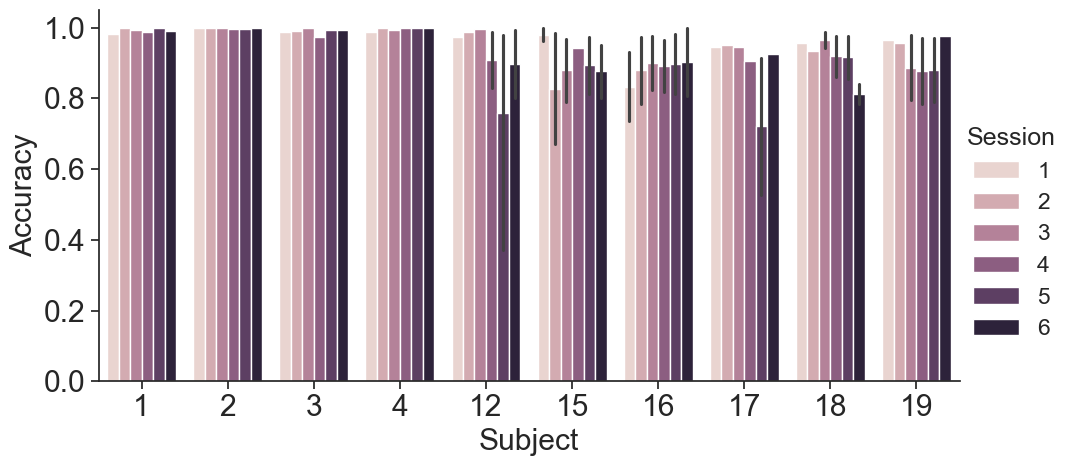

In [8]:
g = sns.catplot(data=acc_df, x='Subject', y='value', hue='Session', kind='bar', height=5, aspect=2)

g.set_axis_labels('Subject', 'Accuracy')
plt.show()

In [9]:
figure_dir = '/home/nmuller/projects/fmg_storage/tux20_oads_eeg_paper_figures'

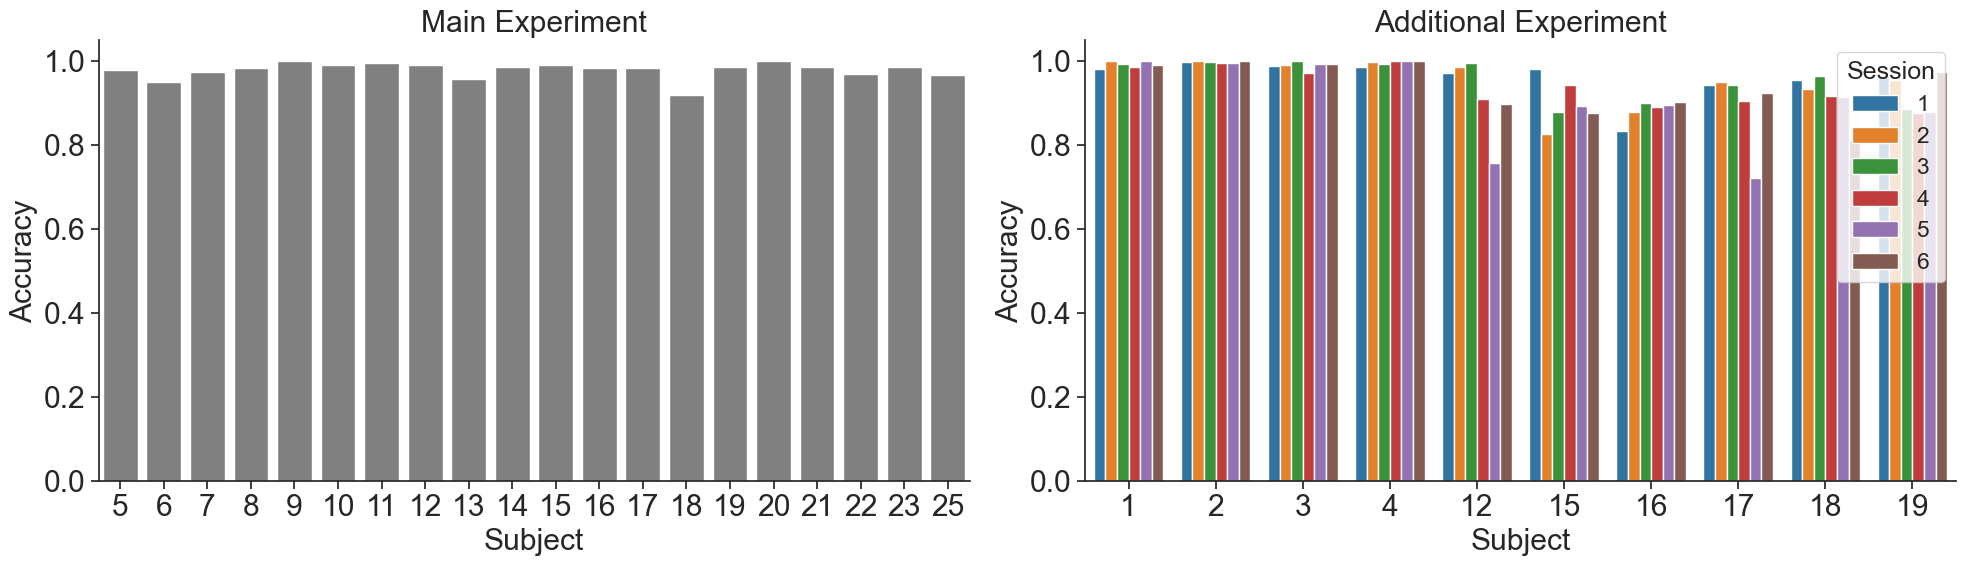

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# main experiment
sns.barplot(data=main_acc_df, x='subject', y='value', ax=ax[0], color='gray') # color=plt.colormaps['viridis'](0.5))
ax[0].set_title('Main Experiment')
ax[0].set_xlabel('Subject')
ax[0].set_ylabel('Accuracy')

# additional experiment
sns.barplot(data=acc_df, x='Subject', y='value', hue='Session', ax=ax[1], errorbar=None, palette='tab10')
ax[1].set_title('Additional Experiment')
ax[1].set_xlabel('Subject')
ax[1].set_ylabel('Accuracy')

sns.despine()
plt.tight_layout()

fig.savefig(os.path.join(figure_dir, 'SUPPL_Fig-5_task_accuracy_per_subject.pdf'), dpi=300, bbox_inches='tight')
plt.show()